In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.src.backend.jax.nn import categorical_crossentropy
from rich import padding
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']

# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')

print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

C:\Users\Weaam\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


# Helper Function

In [3]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
epochs=20, batch_size=128, extra_callbacks=None):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    history = model.fit(x_tr, to_categorical(y_tr, 10),
    validation_data=(x_v, to_categorical(y_v, 10)),
    epochs=epochs, batch_size=batch_size,
    callbacks=cb, verbose=0)

    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time:{elapsed:.1f}")
    return history, test_acc, test_loss, elapsed

def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# 1A. Normalization Comparison

CNN Architecture

In [6]:
def BaselineCNN():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

Experiment A

In [7]:
model_a = BaselineCNN()
history_a, test_acc_a, test_loss_a, time_a = train_and_evaluate(model_a, x_train, y_train, x_val, y_val, x_test, y_test)

Test Acc: 0.5463 | Test Loss: 2.8604 | Time:452.7


Experiment B

In [8]:
x_train_minmax = x_train / 255.0
x_val_minmax = x_val / 255.0
x_test_minmax = x_test / 255.0

model_b = BaselineCNN()
history_b, test_acc_b, test_loss_b, time_b = train_and_evaluate(model_b, x_train_minmax, y_train, x_val_minmax, y_val, x_test_minmax, y_test)

Test Acc: 0.6516 | Test Loss: 1.2742 | Time:412.8


Experiment C

In [9]:
mean = np.mean(x_train, axis=(0, 1, 2))
std = np.std(x_train, axis=(0, 1, 2))

x_train_standardized = (x_train - mean) / std
x_val_standardized = (x_val - mean) / std
x_test_standardized = (x_test - mean) / std

model_c = BaselineCNN()
history_c, test_acc_c, test_loss_c, time_c = train_and_evaluate(model_c, x_train_standardized,y_train, x_val_standardized, y_val, x_test_standardized, y_test)

Test Acc: 0.6704 | Test Loss: 1.9626 | Time:397.2


Visualization

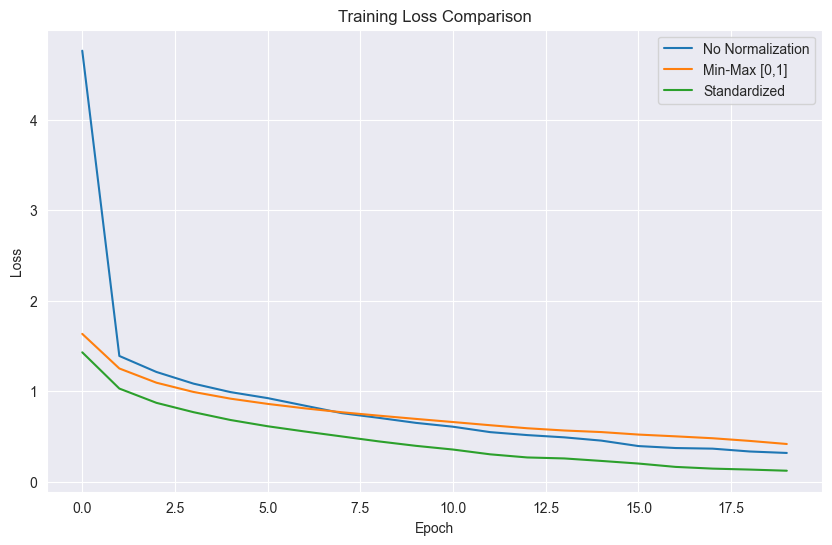

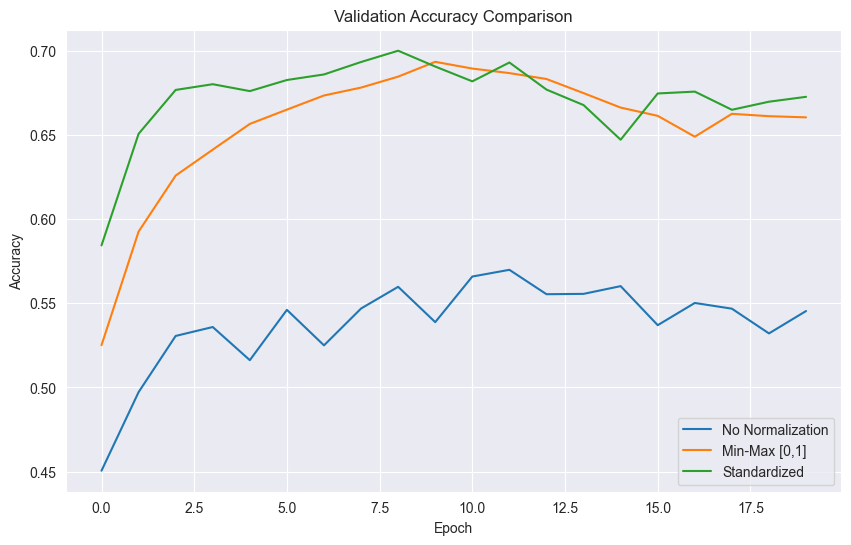

In [10]:
histories = [history_a, history_b, history_c]
plot_curves(histories, labels=['No Normalization', 'Min-Max [0,1]', 'Standardized'],
            metric='loss',
            title='Training Loss Comparison',
            ylabel='Loss')
plot_curves(histories, labels=['No Normalization', 'Min-Max [0,1]', 'Standardized'],
            metric='val_accuracy',
            title='Validation Accuracy Comparison',
            ylabel='Accuracy')

# 1B. Data Augmentation Comparison

In [11]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
    )
datagen.fit(x_train_standardized)

Training BaslinCNN with Data Augmentation

In [12]:
model_no_aug = BaselineCNN()
history_no_aug = model_no_aug.fit(
    x_train_standardized, to_categorical(y_train, 10),
    validation_data=(x_val_standardized, to_categorical(y_val, 10)),
    epochs=40,batch_size=128)

Epoch 1/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.5100 - loss: 1.3872 - val_accuracy: 0.6018 - val_loss: 1.1418
Epoch 2/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.6554 - loss: 0.9902 - val_accuracy: 0.6669 - val_loss: 0.9683
Epoch 3/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.7114 - loss: 0.8402 - val_accuracy: 0.6875 - val_loss: 0.9109
Epoch 4/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step - accuracy: 0.7498 - loss: 0.7298 - val_accuracy: 0.6953 - val_loss: 0.8919
Epoch 5/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.7786 - loss: 0.6391 - val_accuracy: 0.6926 - val_loss: 0.9157
Epoch 6/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.8038 - loss: 0.5685 - val_accuracy: 0.6882 - val_loss: 0.9631
Epoch 7/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.8208 - loss: 0.5129 - val_accuracy: 0.6829 - val_loss: 1.0002
Epoch 8/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.8400 - loss: 0.4577 - 

Training BaslinCNN without Data Augmentation


In [13]:
model_aug = BaselineCNN()
history_aug = model_aug.fit(
    datagen.flow(x_train_standardized ,to_categorical(y_train, 10) ,batch_size=128),
    validation_data=(x_val_standardized, to_categorical(y_val, 10)),
    epochs=40)

Epoch 1/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 177ms/step - accuracy: 0.4582 - loss: 1.5111 - val_accuracy: 0.5788 - val_loss: 1.2031
Epoch 2/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 245ms/step - accuracy: 0.5735 - loss: 1.2109 - val_accuracy: 0.6407 - val_loss: 1.0251
Epoch 3/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 97ms/step - accuracy: 0.6144 - loss: 1.0927 - val_accuracy: 0.6255 - val_loss: 1.1071
Epoch 4/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 224ms/step - accuracy: 0.6446 - loss: 1.0086 - val_accuracy: 0.6652 - val_loss: 0.9706
Epoch 5/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 74s 236ms/step - accuracy: 0.6615 - loss: 0.9647 - val_accuracy: 0.6930 - val_loss: 0.8941
Epoch 6/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 190ms/step - accuracy: 0.6741 - loss: 0.9230 - val_accuracy: 0.6941 - val_loss: 0.9008
Epoch 7/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 57s 183ms/step - accuracy: 0.6881 - loss: 0.8890 - val_accuracy: 0.7023 - val_loss: 0.8724
Epoch 8/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 186ms/step - accuracy: 0.6981 - loss: 0.

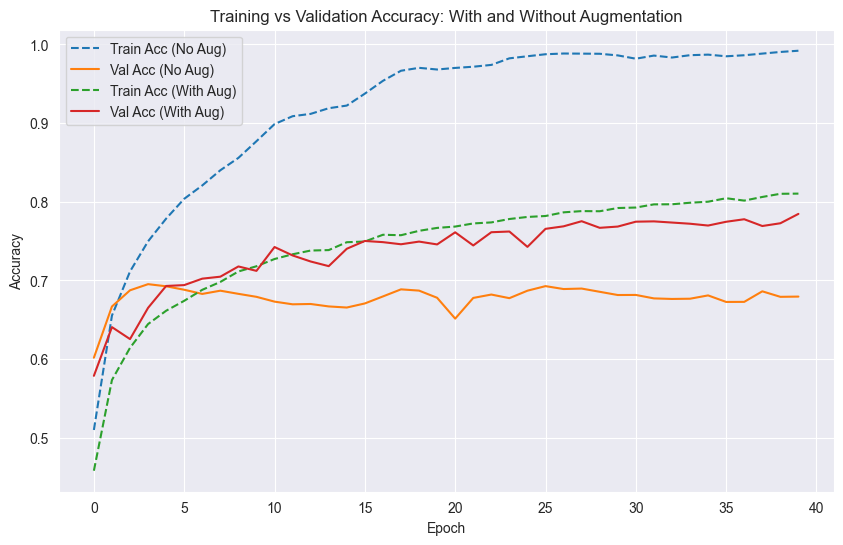

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(history_no_aug.history['accuracy'], label='Train Acc (No Aug)', linestyle='--')
plt.plot(history_no_aug.history['val_accuracy'], label='Val Acc (No Aug)')
plt.plot(history_aug.history['accuracy'], label='Train Acc (With Aug)', linestyle='--')
plt.plot(history_aug.history['val_accuracy'], label='Val Acc (With Aug)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy: With and Without Augmentation')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# without augmentation
train_acc_no_aug = history_no_aug.history['accuracy'][-1]
val_acc_no_aug = history_no_aug.history['val_accuracy'][-1]
gap_no_aug = train_acc_no_aug - val_acc_no_aug

# with augmentation
train_acc_aug = history_aug.history['accuracy'][-1]
val_acc_aug = history_aug.history['val_accuracy'][-1]
gap_aug = train_acc_aug - val_acc_aug

print(f"Without Augmentation -- Train:{train_acc_no_aug:} -- Validation:{val_acc_no_aug:} -- Gap:{gap_no_aug:}")
print(f"With Augmentation -- Train:{train_acc_aug} -- Validation:{val_acc_aug:} -- Gap:{gap_aug:}")
print("Model with smaller gap overfits less:")
if gap_aug > gap_no_aug:
    print("Without Augmentation")
else:
    print("With Augmentation")


Without Augmentation -- Train:0.9919750094413757 -- Validation:0.6794999837875366 -- Gap:0.3124750256538391
With Augmentation -- Train:0.8103749752044678 -- Validation:0.784600019454956 -- Gap:0.02577495574951172
Model with smaller gap overfits less:
With Augmentation


# 2A. Filter Count Comparison

CNN Architecture

In [16]:
from tensorflow import keras
from tensorflow.keras import layers, models

def build_cnn_filters(f1, f2, f3, f4):
    model = models.Sequential([
        layers.Conv2D(f1, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(f2, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(f3, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(f4, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

Small Model

In [17]:
small_model = build_cnn_filters(8, 8, 16, 16)
history_small, test_acc_small, test_loss_small, time_small = train_and_evaluate(small_model, x_train_standardized, y_train, x_val_standardized, y_val, x_test_standardized, y_test)

small_model.summary()

Test Acc: 0.5895 | Test Loss: 2.6382 | Time:119.5


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 807,800 (3.08 MB)

 Trainable params: 269,266 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 538,534 (2.05 MB)

Medium Model

In [ ]:
medium_model = build_cnn_filters(32, 32, 64, 64)
history_medium, test_acc_medium, test_loss_medium, time_medium = train_and_evaluate(medium_model, x_train_standardized, y_train, x_val_standardized, y_val, x_test_standardized, y_test)

medium_model.summary()

Large Model

In [ ]:
large_model = build_cnn_filters(64, 64, 128, 128)
history_large, test_acc_large, test_loss_large, time_large = train_and_evaluate(large_model, x_train_standardized, y_train, x_val_standardized, y_val, x_test_standardized, y_test)

large_model.summary()

Visualization

In [ ]:
histories = [history_small, history_medium, history_large]
plot_curves(histories, labels=['Small Model', 'Medium Model', 'Large Model'],
            metric='val_accuracy',
            title='Validation Accuracy Comparison',
            ylabel='Accuracy')

# 2B. Network Depth Comparison

CNN Architecture

In [ ]:
def build_cnn_depth(depth=''):
    if depth == 'Shallow':
        model = models.Sequential([
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D(pool_size=(2, 2)),

            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D(pool_size=(2, 2)),

            layers.Flatten(),
            layers.Dense(256, activation='relu'),
            layers.Dense(10, activation='softmax')
        ])

    elif depth == 'Medium':
        model = models.Sequential([
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D(pool_size=(2, 2)),
#-----------------------------------------------------------------------
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D(pool_size=(2, 2)),
#--------------------------------------------------------------------
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.GlobalAveragePooling2D(),

            layers.Dense(256, activation='relu'),
            layers.Dense(10, activation='softmax')
        ])

    elif depth == 'Deep':
        model = models.Sequential([
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D(pool_size=(2, 2)),
#----------------------------------------------------------------------
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D(pool_size=(2, 2)),
#----------------------------------------------------------------------
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D(pool_size=(2, 2)),

#----------------------------------------------------------------------
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.GlobalAveragePooling2D(),

            layers.Dense(256, activation='relu'),
            layers.Dense(10, activation='softmax')
        ])

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

Shallow Model

In [ ]:
shallow_model = build_cnn_depth('Shallow')
history_shallow, test_acc_shallow, test_loss_shallow, time_shallow = train_and_evaluate(shallow_model, x_train_standardized, y_train, x_val_standardized, y_val, x_test_standardized, y_test)

Medium Model

In [ ]:
medium_model = build_cnn_depth('Medium')
history_medium, test_acc_medium, test_loss_medium, time_medium = train_and_evaluate(medium_model, x_train_standardized, y_train, x_val_standardized, y_val, x_test_standardized, y_test)

Deep Model

In [ ]:
deep_model = build_cnn_depth('Deep')
history_deep, test_acc_deep, test_loss_deep, time_deep = train_and_evaluate(deep_model, x_train_standardized, y_train, x_val_standardized, y_val, x_test_standardized, y_test)

Visualization

In [ ]:
histories = [history_shallow, history_medium, history_deep]
model_names = ['Shallow', 'Medium', 'Deep']

for history, name in zip(histories, model_names):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{name} Model — Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()